In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline
pd.set_option('display.max_rows', 200)

## Load data files, and adjust indexes and columns

In [3]:
# Load raw data for Consumer Price Index and Unemployment rate
# Set the DATE column as index for timeseries after parsing as date data type
# Fix sp500 column names in addition to changing DATE as index and converting to date

df_cpi = pd.read_csv("./sp500_comprehensive/economic_CPI.csv", index_col="DATE", parse_dates=["DATE"])
df_unrate = pd.read_csv("./sp500_comprehensive/economic_UNRATE.csv", index_col="DATE", parse_dates=["DATE"])
df_sp500 = pd.read_csv("./sp500_comprehensive/sp500_index.csv", header=0, names=['DATE', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker'], index_col="DATE", parse_dates=["DATE"])

## Cleanup after inspection of data

In [4]:
# Check loaded dataframes if they needs cleanup

df_cpi.info(), df_unrate.info(), df_sp500.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 673 entries, 1970-01-01 to 2026-01-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CPIAUCSL  672 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 673 entries, 1970-01-01 to 2026-01-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   UNRATE  672 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14155 entries, 1970-01-02 to 2026-02-20
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   14155 non-null  float64
 1   High    14155 non-null  float64
 2   Low     14155 non-null  float64
 3   Open    14155 non-null  float64
 4   Volume  14155 non-null  int64  
 5   Ticker  14155 non-null  object 
dtypes: float64(4), int

(None, None, None)

In [5]:
# First two datasets have a row of data missing. As this is monthly data we can ffill the data

df_cpi["CPIAUCSL"] = df_cpi["CPIAUCSL"].ffill()
df_unrate["UNRATE"] = df_unrate["UNRATE"].ffill()

In [6]:
# Check stats after ffill

df_cpi.info(), df_unrate.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 673 entries, 1970-01-01 to 2026-01-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CPIAUCSL  673 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 673 entries, 1970-01-01 to 2026-01-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   UNRATE  673 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB


(None, None)

## Transformation, merging and feature engineering

#### CPI (Consumer Price Index) and UNRATE (Unemployment Rate) datasets are monthly data, we can join them into a single one which we can join with sp500 (S&P 500) index data

In [7]:
# Merge both CPI and UNRATE dataframes, using join as we have index's on both sides

df_eco = df_cpi.join(df_unrate)

#### S&P dataset is daily, resampling to monthly to join with df_eco

In [8]:
df_sp500_monthly = df_sp500.resample("MS").first()

In [9]:
df_sp500_monthly.head()

,Close,High,Low,Open,Volume,Ticker
DATE,,,,,,
1970-01-01,93.000000,93.540001,91.790001,92.059998,8050000,^GSPC
1970-02-01,85.750000,86.760002,84.760002,85.019997,13440000,^GSPC
1970-03-01,89.709999,90.800003,88.919998,89.500000,12270000,^GSPC
1970-04-01,90.070000,90.620003,89.300003,89.629997,9810000,^GSPC
1970-05-01,81.440002,82.320000,80.269997,81.519997,8290000,^GSPC


#### Analyze how the data looks after we join index monthly resampled data with economic data

In [10]:
df_processed = df_sp500_monthly.join(df_eco, how="left")
df_processed.query("CPIAUCSL.isnull()")

,Close,High,Low,Open,Volume,Ticker,CPIAUCSL,UNRATE
DATE,,,,,,,,
2026-02-01,6976.439941,6991.919922,6914.339844,6916.640137,5772050000,^GSPC,NaN,NaN


#### We have a row missing from latest economic data so we will drop this

In [11]:
df_processed.dropna(subset=["CPIAUCSL", "UNRATE"], inplace=True)
df_processed.isnull().any(), len(df_processed)

(Close       False
 High        False
 Low         False
 Open        False
 Volume      False
 Ticker      False
 CPIAUCSL    False
 UNRATE      False
 dtype: bool,
 673)

#### Calculating yearly inflation from CPI

In [12]:
# Calculating yearly percent change for CPI as this is a slow changing

df_processed["CPI_yearly_inflation"] = df_processed.CPIAUCSL.pct_change(12) * 100

#### Calculating monthly market returns

In [13]:
df_processed["Monthly_returns"] = df_processed.Close.pct_change() * 100

#### Generate a cleaned dataset dropping null values generated from percentage change calculation

In [14]:
df_processed.dropna(subset=["CPI_yearly_inflation", "Monthly_returns"], inplace=True)

## Analysis: Inflation, Unemployment, and Stock Market Returns

### Yearly inflation rate (CPI), 1971–2026. Gray dashed line = 5% high‑inflation threshold
This chart shows how fast prices went up each year. The gray line at 5% helps you spot periods of high inflation, like the 1970s and 2021–2023.  
**Findings**: *Over 50 years, US inflation has seen two major spikes above 5%: the 1970s oil crises and the 2021–2023 post‑pandemic period. Most other years stayed below 3%.*

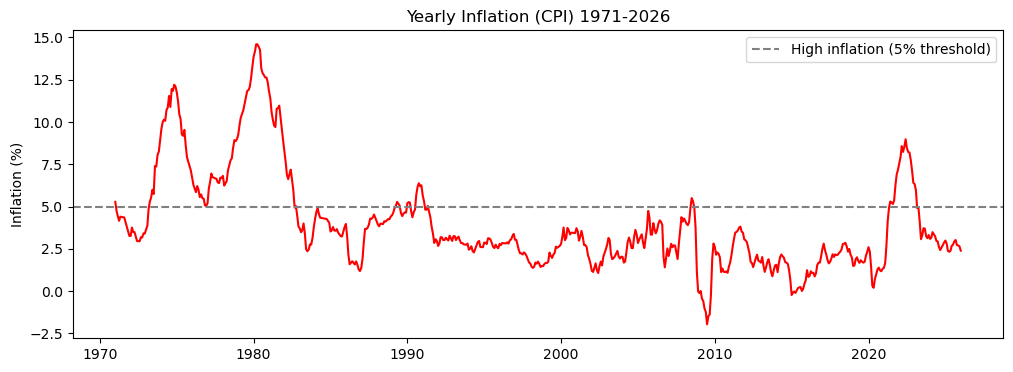

In [15]:
plt.figure(figsize=(12,4))
plt.plot(df_processed.index, df_processed['CPI_yearly_inflation'], color='red')
plt.axhline(y=5, color='gray', linestyle='--', label='High inflation (5% threshold)')
plt.title('Yearly Inflation (CPI) 1971-2026')
plt.ylabel('Inflation (%)')
# plt.grid(True)
plt.legend()
plt.show()

###  Inflation vs. Monthly S&P 500 Returns
Each dot is one month. It compares inflation (horizontal axis) to how much the stock market gained or lost that month (vertical axis). Most dots cluster near zero – meaning no strong relationship month to month.  
**Findings**: *The densest cluster of months occurred when yearly inflation was around 2.5% and monthly returns were near zero. This reflects the long period of stable inflation and modest average returns, but does not imply a predictive relationship.*

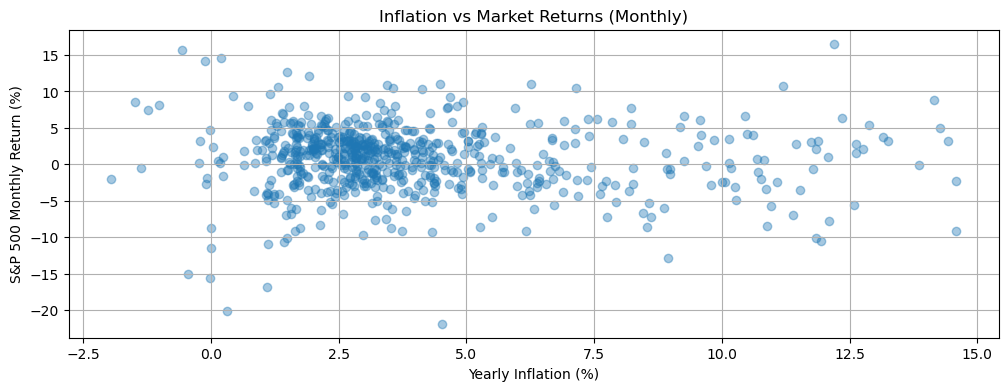

In [16]:
plt.figure(figsize=(12, 4))
plt.scatter(df_processed['CPI_yearly_inflation'], df_processed['Monthly_returns'], alpha=0.4)
plt.xlabel('Yearly Inflation (%)')
plt.ylabel('S&P 500 Monthly Return (%)')
plt.title('Inflation vs Market Returns (Monthly)')
plt.grid(True)
plt.show()

### 10-Year Rolling S&P 500 Returns vs. 10-Year Average Inflation
The top chart shows the cumulative total return of the S&P 500 over the previous 10 years. The bottom chart shows the average yearly inflation over the same 10‑year window. Both share the same time axis, making it easy to compare long‑term patterns.  
**Findings**: *Periods with high average inflation (red line above 5%, e.g., late 1970s) align with low or negative 10‑year stock returns (green line). When inflation is low and stable (1990s, 2010s), 10‑year returns are strongly positive. This confirms that persistent high inflation erodes long‑term market performance, even though short‑term monthly relationships are weak.*

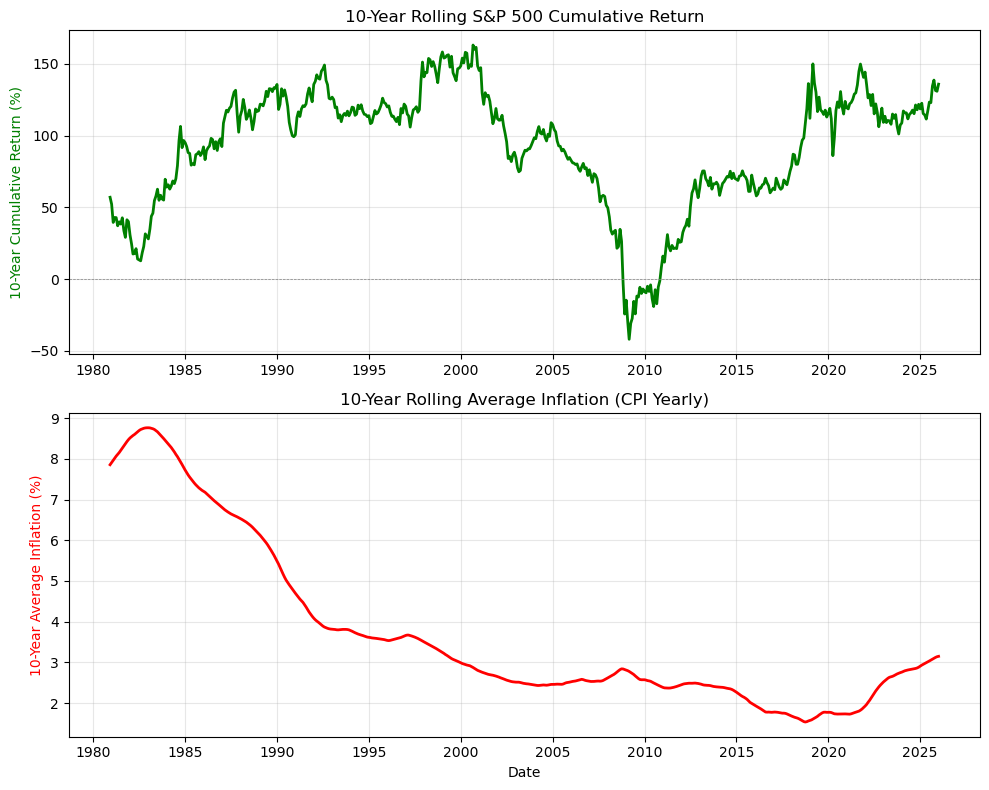

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# 120 months = 10y
df_processed['10Y_return'] = df_processed['Monthly_returns'].rolling(120).sum()
df_processed['10Y_inflation'] = df_processed['CPI_yearly_inflation'].rolling(120).mean()

# Top plot: 10-year cumulative stock returns
ax1.plot(df_processed.index, df_processed['10Y_return'], color='green', linewidth=2)
ax1.set_ylabel('10-Year Cumulative Return (%)', color='green')
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax1.grid(True, alpha=0.3)
ax1.set_title('10-Year Rolling S&P 500 Cumulative Return')

# Bottom plot: 10-year average inflation
ax2.plot(df_processed.index, df_processed['10Y_inflation'], color='red', linewidth=2)
ax2.set_ylabel('10-Year Average Inflation (%)', color='red')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.set_title('10-Year Rolling Average Inflation (CPI Yearly)')

plt.tight_layout()
plt.show()

### Unemployment Rate vs. S&P 500 Index (Monthly)
The top chart shows the monthly unemployment rate. The bottom chart shows the S&P 500 closing price. Both share the same time axis.  
**Findings**: *Unemployment rises only after major market crashes (2008, 2020), not after every dip. It falls during long bull markets. This confirms unemployment is a lagging indicator, not a predictor.*

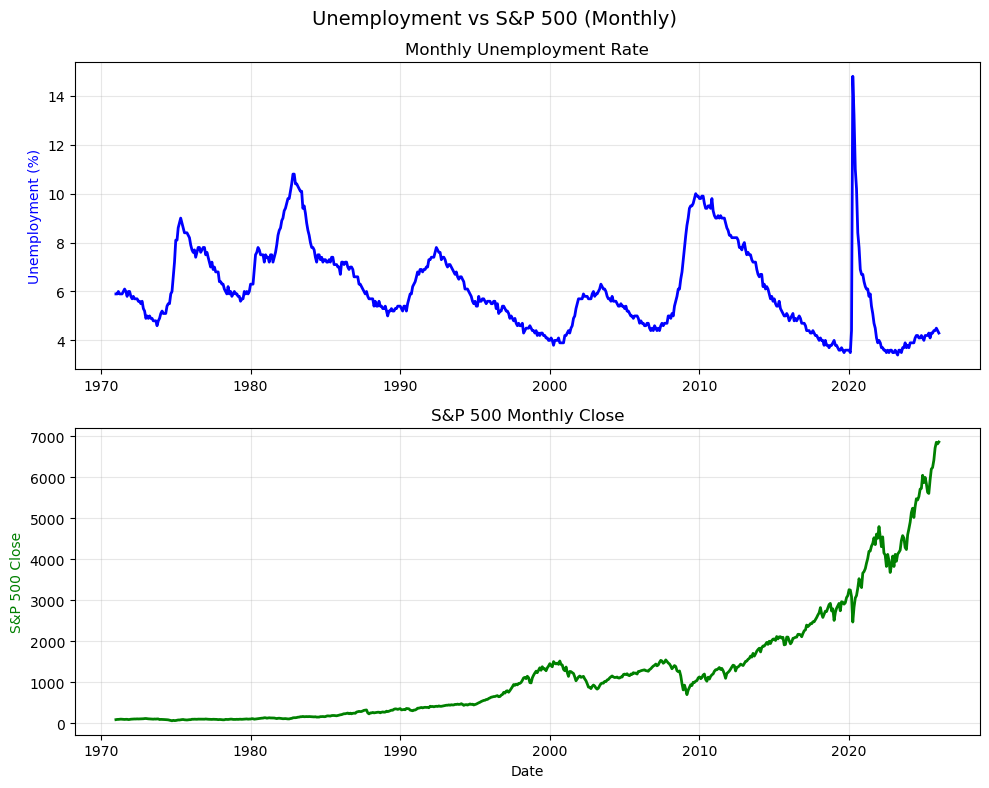

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top plot: Unemployment rate
ax1.plot(df_processed.index, df_processed['UNRATE'], color='blue', linewidth=2)
ax1.set_ylabel('Unemployment (%)', color='blue')
ax1.grid(True, alpha=0.3)
ax1.set_title('Monthly Unemployment Rate')

# Bottom plot: S&P 500 Close
ax2.plot(df_processed.index, df_processed['Close'], color='green', linewidth=2)
ax2.set_ylabel('S&P 500 Close', color='green')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.set_title('S&P 500 Monthly Close')

plt.suptitle('Unemployment vs S&P 500 (Monthly)', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
corr = df_processed[['Monthly_returns', 'CPI_yearly_inflation', 'UNRATE']].corr()
corr

,Monthly_returns,CPI_yearly_inflation,UNRATE
Monthly_returns,1.000000,-0.066894,0.045610
CPI_yearly_inflation,-0.066894,1.000000,0.067094
UNRATE,0.045610,0.067094,1.000000


## 10‑Year Rolling Stock Returns vs. Average Inflation  
This chart plots 10‑year average inflation (horizontal axis) against 10‑year cumulative stock returns (vertical axis). Each dot represents one rolling 10‑year window, advancing month by month from 1971 to 2026. The correlation between the two is shown on the plot.  
**Findings**: *Over 10‑year rolling periods, higher average inflation consistently leads to lower cumulative stock returns.*

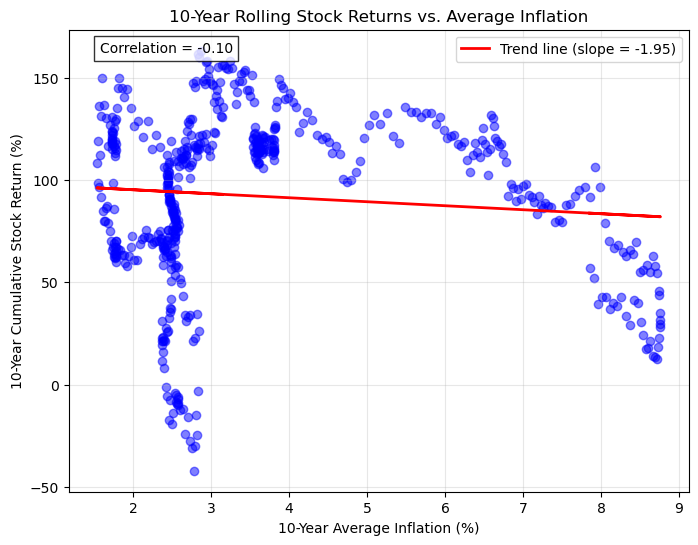

In [20]:
# Drop NaN rows from rolling calculation
df_10y = df_processed.dropna(subset=['10Y_return', '10Y_inflation'])

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df_10y['10Y_inflation'], df_10y['10Y_return'], alpha=0.5, color='blue')

# Add a regression line (trend line)
z = np.polyfit(df_10y['10Y_inflation'], df_10y['10Y_return'], 1)
p = np.poly1d(z)
plt.plot(df_10y['10Y_inflation'], p(df_10y['10Y_inflation']), color='red', linewidth=2, label=f'Trend line (slope = {z[0]:.2f})')

plt.xlabel('10-Year Average Inflation (%)')
plt.ylabel('10-Year Cumulative Stock Return (%)')
plt.title('10-Year Rolling Stock Returns vs. Average Inflation')
plt.legend()
plt.grid(True, alpha=0.3)

# Display correlation on plot
corr_value = df_10y['10Y_return'].corr(df_10y['10Y_inflation'])
plt.text(0.05, 0.95, f'Correlation = {corr_value:.2f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.show()